In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xmf6
from gypsum import plot

In [2]:
def lee(file):
    # Leer información de "u_init.dat"
    with open(file_path, "r") as f:
        lines = f.readlines()

    key_string = "Initial concentration of aqueous species:"
    i = xmf6.find_index(lines, key_string, 2)
    ini = [np.array(l.split(), dtype=float) for l in lines[i:i+3]]
    
    key_string = "Final concentration of aqueous species:"
    i = xmf6.find_index(lines, key_string, 2)
    fin = [np.array(l.split(), dtype=float) for l in lines[i:i+3]]

    return ini, fin

In [4]:
#wma_working_dir = r"C:\Users\luiggi\Documents\GitSites\RTWMA\benchmarks\03_wma\RT-EXE"
wma_working_dir = r"../RT-EXE/"
tr1d_ofile='gypsum_eq.out'
file_path = os.path.join(wma_working_dir, tr1d_ofile)
tr1d_ofile_tvd='gypsum_eq_tvd.out'
file_path_tvd = os.path.join(wma_working_dir, tr1d_ofile_tvd)
tr1d_ofile_dfc='gypsum_eq_dfc.out'
file_path_dfc = os.path.join(wma_working_dir, tr1d_ofile_dfc)

# ----- DATOS CALCULADOS -----
wma_mf6_ini, wma_mf6_fin = lee(file_path)
wma_tvd_ini, wma_tvd_fin = lee(file_path_tvd)
wma_dfc_ini, wma_dfc_fin = lee(file_path_dfc)

c1_mf6 = np.asarray(wma_mf6_fin[0])
c2_mf6 = np.asarray(wma_mf6_fin[1])
u_mf6 = c1_mf6 - c2_mf6

c1_dfc= np.asarray(wma_dfc_fin[0])
c2_dfc = np.asarray(wma_dfc_fin[1])
u_dfc = c1_dfc - c2_dfc

# ----- DATOS DEL EXCEL -----
c1 = pd.read_excel('comparativa_02.xlsx', sheet_name='c_1')  
c1 = np.transpose(c1.iloc[11:,5:95].to_numpy())
c1 = c1[10]

c2 = pd.read_excel('comparativa_02.xlsx', sheet_name='c_2')  
c2 = np.transpose(c2.iloc[11:,5:95].to_numpy())
c2 = c2[10]

# ----- SOLUCIÓN ANALÍTICA -----
u = pd.read_excel('comparativa_02.xlsx', sheet_name='Anl_u')  
u = np.transpose(u.iloc[11:,5:95].to_numpy())
u = u[1]

anc1 = pd.read_excel('comparativa_02.xlsx', sheet_name='An_C1')  
anc1 = np.transpose(anc1.iloc[11:,5:95].to_numpy())
anc1 = anc1[1]

anc2 = pd.read_excel('comparativa_02.xlsx', sheet_name='An_C2')  
anc2 = np.transpose(anc2.iloc[11:,5:95].to_numpy())
anc2 = anc2[1]

x = np.arange(0.5, 30, 1.0)

In [5]:
# Calculamos el RMSE
N = len(c1)
RMSE_u_mf6 = np.linalg.norm(u-u_mf6) / np.sqrt(N)
RMSE_c1_mf6 = np.linalg.norm(anc1-c1_mf6) / np.sqrt(N)
RMSE_c2_mf6 = np.linalg.norm(anc2-c2_mf6) / np.sqrt(N)

RMSE_u_dfc = np.linalg.norm(u-u_dfc) / np.sqrt(N)
RMSE_c1_dfc = np.linalg.norm(anc1-c1_dfc) / np.sqrt(N)
RMSE_c2_dfc = np.linalg.norm(anc2-c2_dfc) / np.sqrt(N)

MAPE_u_mf6 = np.mean(np.abs((u - u_mf6) / u)) * 100 
MAPE_c1_mf6 = np.mean(np.abs((anc1 - c1_mf6) / anc1)) * 100 
MAPE_c2_mf6 = np.mean(np.abs((anc2 - c2_mf6) / anc2)) * 100 

MAPE_u_dfc = np.mean(np.abs((u - u_dfc) / u)) * 100 
MAPE_c1_dfc = np.mean(np.abs((anc1 - c1_dfc) / anc1)) * 100 
MAPE_c2_dfc = np.mean(np.abs((anc2 - c2_dfc) / anc2)) * 100 

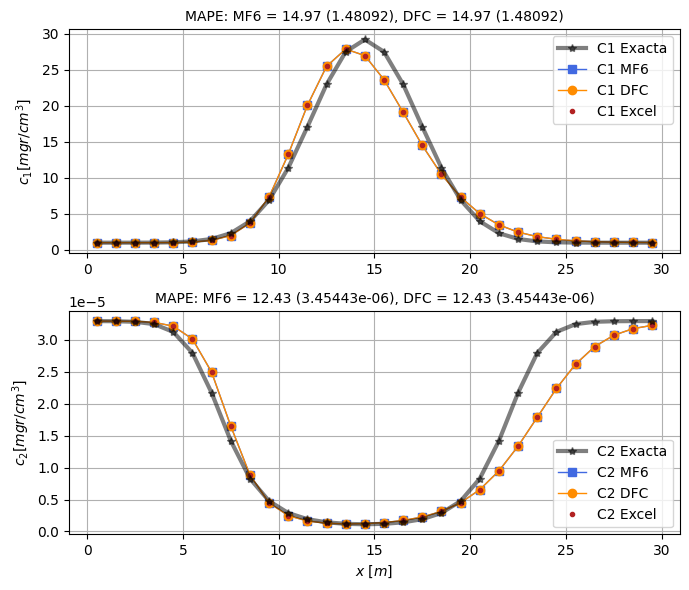

In [6]:
fig, ax = plt.subplots(2, 1, figsize=(7,6))
ax[0].plot(x, anc1, "*-", c = "black", lw=3.0, alpha=0.5, label="C1 Exacta", zorder=6)
ax[0].plot(x, c1_mf6, "s-", c = "royalblue", lw = 1.0, label="C1 MF6", zorder=5)
###ax[0].plot(x, wma_tvd_fin[0], "o-", c = "purple" , lw = 1.0, label="C1 MF6-TVD", zorder=5)
ax[0].plot(x, c1_dfc, "o-", c = "darkorange", lw = 1.0, label="C1 DFC", zorder=5)
ax[0].plot(x, c1, ".", c = "firebrick", label="C1 Excel", zorder=5)
ax[0].set_title(f"MAPE: MF6 = {MAPE_c1_mf6:2.2f} ({RMSE_c1_mf6:2.5f}), DFC = {MAPE_c1_dfc:2.2f} ({RMSE_c1_dfc:2.5f})", fontsize=10)
ax[0].set_ylabel("$c_1 [mgr/cm^{3}]$")
ax[0].grid()
ax[0].legend()

ax[1].plot(x, anc2, "*-", c = "black", lw=3.0, alpha=0.5, label="C2 Exacta", zorder=6)
ax[1].plot(x, c2_mf6, "s-", c = "royalblue", lw = 1.0, label="C2 MF6", zorder=5)
###ax[1].plot(x, wma_tvd_fin[1], "o-", c = "purple" , lw = 1.0, label="C2 MF6-TVD", zorder=5)
ax[1].plot(x, c2_dfc, "o-", c = "darkorange", lw = 1.0, label="C2 DFC", zorder=5)
ax[1].plot(x, c2, ".", c = "firebrick", label="C2 Excel", zorder=5)
ax[1].set_title(f"MAPE: MF6 = {MAPE_c2_mf6:2.2f} ({RMSE_c2_mf6:2.5e}), DFC = {MAPE_c2_dfc:2.2f} ({RMSE_c2_dfc:2.5e})", fontsize=10)
ax[1].set_xlabel("$x$ [$m$]")
ax[1].set_ylabel("$c_2 [mgr/cm^{3}]$")
ax[1].grid()
ax[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

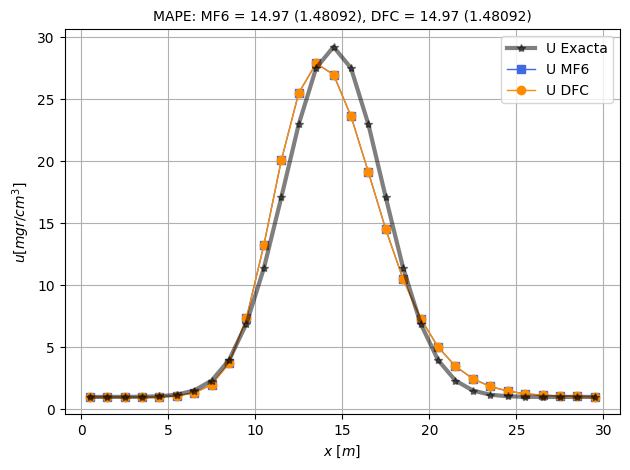

In [7]:
fig, ax = plt.subplots(1, 1)
ax.plot(x, u, "*-", c = "black", lw=3.0, alpha=0.5, label="U Exacta", zorder=6)
ax.plot(x, u_mf6, "s-", c = "royalblue", lw = 1.0, label="U MF6", zorder=5)
ax.plot(x, u_dfc, "o-", c = "darkorange", lw = 1.0, label="U DFC", zorder=5)
ax.set_title(f"MAPE: MF6 = {MAPE_u_mf6:2.2f} ({RMSE_u_mf6:2.5f}), DFC = {MAPE_u_dfc:2.2f} ({RMSE_u_dfc:2.5f})", fontsize=10)
ax.set_xlabel("$x$ [$m$]")
ax.set_ylabel("$u [mgr/cm^{3}]$")
ax.grid()
ax.legend(loc="upper right")

plt.tight_layout()
plt.show()